<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/12th_April_Ensemble_Techniques_And_Its_Types_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Data Science Masters

## Q1. How Does Bagging Reduce Overfitting in Decision Trees?

### The Overfitting Problem in Decision Trees
A fully grown decision tree memorizes the training data — it is a **high-variance, low-bias** model. Small changes in the training set can produce very different trees. This is exactly what bagging exploits.

### How Bagging Fixes This — Step by Step

**1. Bootstrap Sampling introduces diversity**  
Each tree is trained on a different random subset of the data (drawn *with replacement*). No two trees see exactly the same training set, so each tree overfits to a *different* part of the noise.

**2. Averaging cancels out noise**  
When predictions from many trees are averaged, the random errors (caused by overfitting to noise) tend to cancel each other out. The shared signal, however, reinforces itself.

$$\text{Var}\left(\bar{X}\right) = \frac{\sigma^2}{B} \quad \text{(if trees were independent)}$$

In practice trees are correlated (correlation } $\rho$), so:
$$\text{Var}_{\text{ensemble}} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, variance → $\rho\sigma^2$. Diversity (low $\rho$) is key.

**3. Bias stays the same**  
Each tree is still fully grown (low bias). Averaging does not change bias, only variance. So bagging achieves **low bias + low variance**.

### Summary Table
| Property | Single Deep Tree | Bagged Trees |
|----------|-----------------|-------------|
| Bias | Low | Low (unchanged) |
| Variance | **High** | **Low** |
| Overfitting | Severe | Greatly reduced |
| Interpretability | High | Low |
| Stability | Low | High |

### Key Insight
> Bagging works best when the base learner is **unstable** — small changes in data cause large changes in the model. Decision trees are highly unstable, making them the ideal base learner for bagging.

---
## Q2. Advantages and Disadvantages of Different Base Learners in Bagging

The choice of base learner significantly impacts the effectiveness of bagging. Here is a comprehensive analysis:

### 1. Decision Trees (Most Common)
| | Detail |
|---|---|
| **Advantages** | High variance → bagging helps most; handles non-linear data; no scaling needed; fast to train |
| **Disadvantages** | Low interpretability when bagged; memory intensive for deep trees |
| **Best for** | General purpose classification & regression |

### 2. Linear Models (Logistic/Linear Regression)
| | Detail |
|---|---|
| **Advantages** | Fast training; interpretable individually; stable |
| **Disadvantages** | Already low variance → bagging gives little benefit; high bias remains; cannot capture non-linearity |
| **Best for** | Almost never used with bagging (use boosting instead) |

### 3. k-Nearest Neighbors (kNN)
| | Detail |
|---|---|
| **Advantages** | Non-parametric; bagging improves stability |
| **Disadvantages** | Very slow at prediction; memory heavy; sensitive to irrelevant features |
| **Best for** | Small datasets with few features |

### 4. Neural Networks
| | Detail |
|---|---|
| **Advantages** | Can learn very complex patterns; bagging reduces variance |
| **Disadvantages** | Extremely slow to train multiple networks; high compute cost |
| **Best for** | When accuracy is critical and compute is available (rarely done in practice) |

### 5. Support Vector Machines (SVM)
| | Detail |
|---|---|
| **Advantages** | Works well in high-dimensional spaces |
| **Disadvantages** | Slow training; kernel selection is tricky; bagging benefit is marginal |
| **Best for** | Rarely used with bagging |

### The Golden Rule for Base Learner Selection:
> **Bagging benefits high-variance learners most.** If your base learner is already stable (low variance), bagging adds little value and only increases computational cost.

---
## Q3. How Does the Choice of Base Learner Affect the Bias-Variance Tradeoff in Bagging?

### The Bias-Variance Decomposition
For any model, the expected prediction error can be decomposed as:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

Bagging **only reduces variance** — it does **not** reduce bias. Therefore:

### Effect on Different Base Learners

```
High Variance Learner (e.g., Deep Tree)
  Before Bagging:  Bias=LOW   Variance=HIGH  → Overfits
  After  Bagging:  Bias=LOW   Variance=LOW   → Best case!

High Bias Learner (e.g., Linear Model)
  Before Bagging:  Bias=HIGH  Variance=LOW   → Underfits
  After  Bagging:  Bias=HIGH  Variance=LOW   → No improvement!

Shallow Tree (medium bias, medium variance)
  Before Bagging:  Bias=MED   Variance=MED
  After  Bagging:  Bias=MED   Variance=LOW   → Moderate benefit
```

### Bias-Variance Matrix
| Base Learner | Bias | Variance | Bagging Benefit |
|-------------|------|----------|----------------|
| Deep Decision Tree | Low | **High** | ✅ Maximum |
| Shallow Decision Tree | Medium | Medium | ✅ Good |
| Linear Regression | **High** | Low | ❌ Minimal |
| kNN (small k) | Low | **High** | ✅ Good |
| kNN (large k) | **High** | Low | ❌ Minimal |
| Neural Network | Low | **High** | ✅ Good (costly) |

### Practical Recommendation:
- Use **fully grown (unpruned) decision trees** as base learners in bagging.
- Adding **random feature selection** at each split (Random Forest) further reduces correlation between trees, lowering variance even more.
- Never prune trees before bagging — pruning increases bias without the variance reduction from aggregation.

---
## Q4. Can Bagging Be Used for Classification and Regression? How Does It Differ?

**Yes — bagging works for both tasks**, but the aggregation strategy differs.

### Classification — Majority Voting

Each of the B trees predicts a class label. The final prediction is the **class that receives the most votes**.

$$\hat{y} = \text{mode}\left(\hat{y}_1, \hat{y}_2, ..., \hat{y}_B\right)$$

**Soft Voting** (using probabilities):
$$P(y=c) = \frac{1}{B}\sum_{b=1}^{B} P_b(y=c)$$

Soft voting is generally preferred as it uses more information.

### Regression — Averaging

Each of the B trees predicts a continuous value. The final prediction is the **mean of all predictions**.

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B} \hat{y}_b$$

### Comparison Table
| Aspect | Classification | Regression |
|--------|---------------|------------|
| Output type | Class label | Continuous value |
| Aggregation | Majority vote (or soft vote) | Mean (or median) |
| Evaluation metric | Accuracy, F1, AUC | MSE, RMSE, MAE, R² |
| Handling imbalance | Weighted voting | Not applicable |
| Outlier sensitivity | Low (voting is robust) | Higher (mean sensitive to outliers; use median) |
| Probability output | Yes (averaged probabilities) | No |

### When to Use Median Instead of Mean (Regression):
If the target variable has outliers, using the **median** of predictions is more robust:
$$\hat{y} = \text{median}\left(\hat{y}_1, ..., \hat{y}_B\right)$$

---
## Q5. What is the Role of Ensemble Size in Bagging? How Many Models Should Be Included?

### Effect of Ensemble Size (B)

The number of base learners B controls the **variance reduction**:

$$\text{Variance}_{\text{ensemble}} = \rho\sigma^2 + \frac{(1-\rho)\sigma^2}{B}$$

- As B increases → variance decreases → better performance (up to a point).
- **Bias is unaffected** by B.
- Beyond a certain B, performance **plateaus** — adding more trees gives diminishing returns.

### Key Observations:

| B (# Trees) | Effect |
|-------------|--------|
| B = 1 | Same as single tree — no benefit |
| B = 10–50 | Significant improvement, large variance reduction |
| B = 100–200 | Near-optimal performance for most datasets |
| B = 500+ | Marginal improvement; mainly computational cost |
| B → ∞ | Variance → $\rho\sigma^2$ (irreducible due to tree correlation) |

### Practical Guidelines:
- **Start with B = 100** as a baseline.
- Use **OOB error** to monitor when performance stabilizes (no need for separate validation set).
- Use **cross-validation** to find the sweet spot.
- For large datasets: B = 100–200 is usually sufficient.
- For small/noisy datasets: B = 300–500 may help.

### Factors Influencing Optimal B:
| Factor | Effect on optimal B |
|--------|--------------------|
| More training data | Lower B needed |
| Noisier data | Higher B needed |
| More features | Higher B helpful |
| Limited compute | Lower B forced |
| High tree correlation | Higher B, but plateau is higher |

> **Rule of thumb**: Plot OOB error vs B and choose the B where the curve flattens.

---
## Q6. Real-World Application of Bagging — Practical Example

### Application: Medical Diagnosis — Breast Cancer Detection

**Domain**: Healthcare / Medical Imaging  
**Task**: Binary Classification — Malignant vs Benign tumor  
**Dataset**: Wisconsin Breast Cancer Dataset (UCI)

### Why Bagging is Ideal Here:
- Medical data is often noisy and limited.
- False negatives (missing cancer) are extremely costly.
- Robust, stable predictions are critical.
- OOB evaluation avoids using precious test data.

### Other Real-World Applications:
| Domain | Task | Why Bagging Helps |
|--------|------|------------------|
| Finance | Credit risk scoring | Reduces overfitting on financial noise |
| Agriculture | Crop yield prediction | Noisy sensor data benefits from averaging |
| E-commerce | Customer churn prediction | Imbalanced, noisy data |
| Meteorology | Weather forecasting | High variance in atmospheric data |
| Cybersecurity | Intrusion detection | Rare event detection needs robust models |

In [ ]:
#  BAGGING — COMPLETE PRACTICAL DEMONSTRATION
#  Application: Breast Cancer Classification

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

# Load Dataset
data   = load_breast_cancer()
X, y   = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset: Breast Cancer Wisconsin")
print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"Train    : {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Classes  : {data.target_names}")

Dataset: Breast Cancer Wisconsin
Features : 30
Samples  : 569
Train    : 455  |  Test: 114
Classes  : ['malignant' 'benign']


In [ ]:
#  PART A — Compare Single Tree vs Bagging
#  (Demonstrates variance reduction)


# Single Decision Tree
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)

# Bagging Classifier (100 trees)
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred_bag  = bagging_clf.predict(X_test)

# Results
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_bag  = accuracy_score(y_test, y_pred_bag)
oob_acc  = bagging_clf.oob_score_

print("━" * 55)
print(f"  Single Decision Tree  Accuracy : {acc_tree:.4f} ({acc_tree*100:.2f}%)")
print(f"  Bagging (100 trees)   Accuracy : {acc_bag:.4f}  ({acc_bag*100:.2f}%)")
print(f"  Bagging OOB Score              : {oob_acc:.4f} ({oob_acc*100:.2f}%)")
print(f"  Improvement                    : +{(acc_bag-acc_tree)*100:.2f}%")
print("━" * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Single Decision Tree  Accuracy : 0.9123 (91.23%)
  Bagging (100 trees)   Accuracy : 0.9386  (93.86%)
  Bagging OOB Score              : 0.9560 (95.60%)
  Improvement                    : +2.63%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
#  PART B — Effect of Ensemble Size (Q5 demonstration)

B_values       = [1, 5, 10, 20, 50, 100, 150, 200, 300, 500]
train_accs     = []
test_accs      = []
oob_scores     = []

for b in B_values:
    clf = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=b,
        bootstrap=True,
        oob_score=(b > 1),
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))
    oob_scores.append(clf.oob_score_ if b > 1 else None)

print("Ensemble size analysis complete!")
print(f"{'B':>5}  {'Train Acc':>10}  {'Test Acc':>10}")
print("-" * 30)
for b, tr, te in zip(B_values, train_accs, test_accs):
    print(f"{b:>5}  {tr*100:>9.2f}%  {te*100:>9.2f}%")

Ensemble size analysis complete!
    B   Train Acc    Test Acc
------------------------------
    1      97.58%      92.11%
    5      99.34%      92.11%
   10      99.56%      92.98%
   20     100.00%      93.86%
   50     100.00%      93.86%
  100     100.00%      93.86%
  150     100.00%      94.74%
  200     100.00%      94.74%
  300     100.00%      94.74%
  500     100.00%      94.74%


In [ ]:
#  PART C — Bias-Variance Analysis (Q3 demonstration)
#  Compare base learners with different bias-variance profiles

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

base_learners = {
    'Deep Tree\n(high var)':      DecisionTreeClassifier(max_depth=None),
    'Shallow Tree\n(med var)':    DecisionTreeClassifier(max_depth=3),
    'KNN k=1\n(high var)':        KNeighborsClassifier(n_neighbors=1),
    'KNN k=15\n(low var)':        KNeighborsClassifier(n_neighbors=15),
    'Logistic\n(low var)':        LogisticRegression(max_iter=1000),
}

results = {}
for name, base in base_learners.items():
    # Solo
    base.fit(X_tr_sc, y_train)
    solo_acc = accuracy_score(y_test, base.predict(X_te_sc))
    # CV variance
    cv_scores = cross_val_score(base, X_tr_sc, y_train, cv=10)
    solo_var  = cv_scores.var()
    # Bagged
    bag = BaggingClassifier(estimator=base, n_estimators=100,
                             bootstrap=True, random_state=42, n_jobs=-1)
    bag.fit(X_tr_sc, y_train)
    bag_acc = accuracy_score(y_test, bag.predict(X_te_sc))
    cv_bag  = cross_val_score(bag, X_tr_sc, y_train, cv=5)
    bag_var = cv_bag.var()

    results[name] = {
        'solo_acc': solo_acc, 'solo_var': solo_var,
        'bag_acc':  bag_acc,  'bag_var':  bag_var,
        'acc_gain': bag_acc - solo_acc,
        'var_reduc': solo_var - bag_var
    }

print(f"{'Learner':<22} {'Solo Acc':>9} {'Bag Acc':>9} {'Gain':>8} {'Var Reduc':>11}")
print("-" * 62)
for name, r in results.items():
    label = name.replace('\n', ' ')
    print(f"{label:<22} {r['solo_acc']*100:>8.2f}% {r['bag_acc']*100:>8.2f}% "
          f"{r['acc_gain']*100:>+7.2f}% {r['var_reduc']*1000:>9.4f}e-3")

Learner                 Solo Acc   Bag Acc     Gain   Var Reduc
--------------------------------------------------------------
Deep Tree (high var)      90.35%    93.86%   +3.51%    0.2429e-3
Shallow Tree (med var)    93.86%    94.74%   +0.88%    0.5244e-3
KNN k=1 (high var)        93.86%    93.86%   +0.00%    0.6544e-3
KNN k=15 (low var)        97.37%    97.37%   +0.00%    0.2176e-3
Logistic (low var)        98.25%    98.25%   +0.00%    0.5028e-3


In [ ]:
#  PART D — Classification Report & Confusion Matrix

print("CLASSIFICATION REPORT — Bagging Classifier")
print("=" * 55)
print(classification_report(y_test, y_pred_bag,
                             target_names=data.target_names))

cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_bag  = confusion_matrix(y_test, y_pred_bag)
print("Confusion Matrix — Single Tree:")
print(cm_tree)
print("\nConfusion Matrix — Bagging:")
print(cm_bag)

CLASSIFICATION REPORT — Bagging Classifier
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix — Single Tree:
[[39  3]
 [ 7 65]]

Confusion Matrix — Bagging:
[[38  4]
 [ 3 69]]


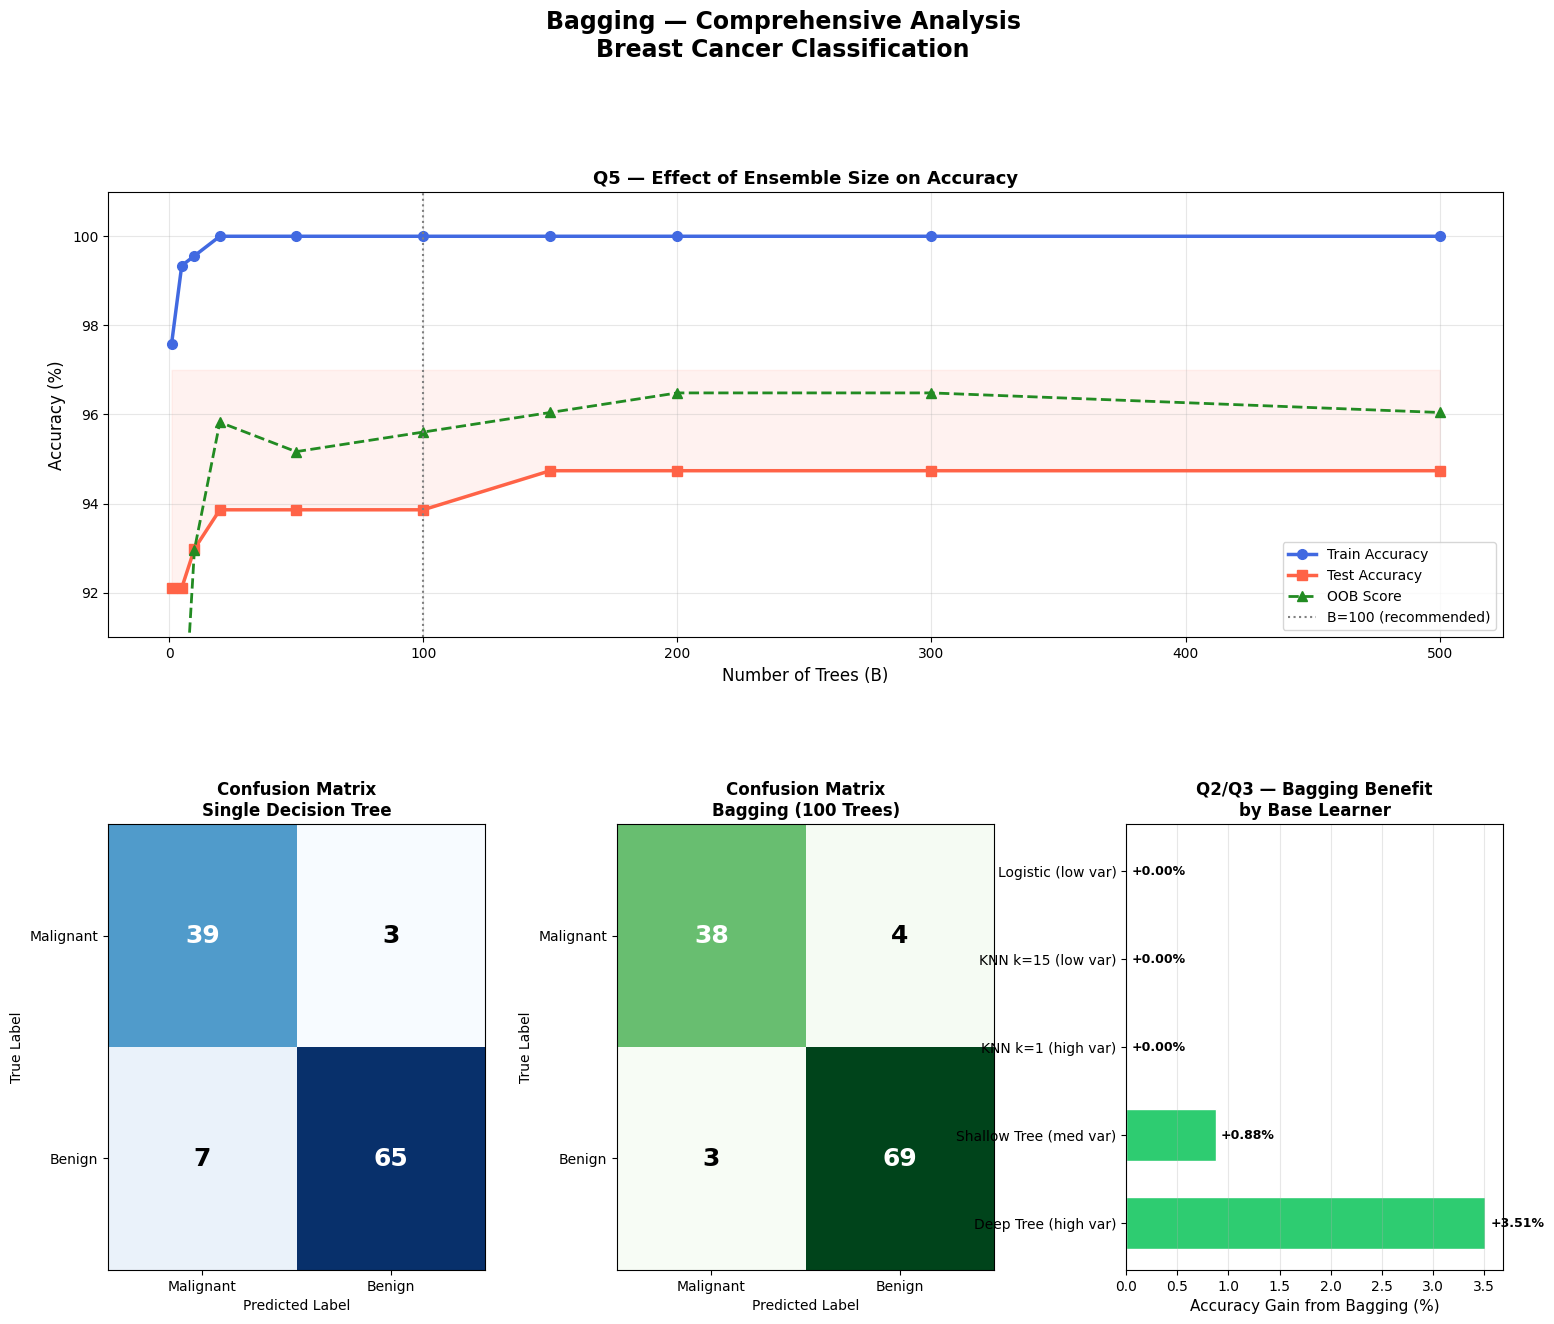

All visualizations complete!


In [ ]:
#  PART E — VISUALIZATIONS (4 plots)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Bagging — Comprehensive Analysis\nBreast Cancer Classification',
             fontsize=17, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

#  Plot 1: Ensemble Size vs Accuracy (Q5)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(B_values, [t*100 for t in train_accs], 'o-', color='royalblue',
         linewidth=2.5, markersize=7, label='Train Accuracy')
ax1.plot(B_values, [t*100 for t in test_accs], 's-', color='tomato',
         linewidth=2.5, markersize=7, label='Test Accuracy')
oob_vals = [v*100 for v in oob_scores if v is not None]
ax1.plot(B_values[1:], oob_vals, '^--', color='forestgreen',
         linewidth=2, markersize=7, label='OOB Score')

ax1.axvline(100, color='gray', linestyle=':', linewidth=1.5, label='B=100 (recommended)')
ax1.fill_between(B_values, [t*100 for t in test_accs], [97]*len(B_values),
                 alpha=0.08, color='tomato')
ax1.set_xlabel('Number of Trees (B)', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Q5 — Effect of Ensemble Size on Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim(91, 101)
ax1.grid(alpha=0.3)

#  Plot 2: Confusion Matrix — Single Tree
ax2 = fig.add_subplot(gs[1, 0])
im2 = ax2.imshow(cm_tree, cmap='Blues', aspect='auto')
ax2.set_title('Confusion Matrix\nSingle Decision Tree', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm_tree[i, j]), ha='center', va='center',
                 fontsize=18, fontweight='bold',
                 color='white' if cm_tree[i,j] > cm_tree.max()/2 else 'black')
ax2.set_xticks([0, 1]); ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Malignant', 'Benign'], fontsize=10)
ax2.set_yticklabels(['Malignant', 'Benign'], fontsize=10)
ax2.set_ylabel('True Label'); ax2.set_xlabel('Predicted Label')

#  Plot 3: Confusion Matrix — Bagging
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(cm_bag, cmap='Greens', aspect='auto')
ax3.set_title('Confusion Matrix\nBagging (100 Trees)', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm_bag[i, j]), ha='center', va='center',
                 fontsize=18, fontweight='bold',
                 color='white' if cm_bag[i,j] > cm_bag.max()/2 else 'black')
ax3.set_xticks([0, 1]); ax3.set_yticks([0, 1])
ax3.set_xticklabels(['Malignant', 'Benign'], fontsize=10)
ax3.set_yticklabels(['Malignant', 'Benign'], fontsize=10)
ax3.set_ylabel('True Label'); ax3.set_xlabel('Predicted Label')

# Plot 4: Base Learner Comparison — Accuracy Gain (Q2 & Q3)
ax4 = fig.add_subplot(gs[1, 2])
learner_names = [n.replace('\n', ' ') for n in results.keys()]
gains = [r['acc_gain']*100 for r in results.values()]
colors_bar = ['#2ecc71' if g > 0 else '#e74c3c' for g in gains]
bars = ax4.barh(learner_names, gains, color=colors_bar, edgecolor='white', height=0.6)
ax4.axvline(0, color='black', linewidth=1.2)
for bar, gain in zip(bars, gains):
    ax4.text(gain + (0.05 if gain >= 0 else -0.05),
             bar.get_y() + bar.get_height()/2,
             f'{gain:+.2f}%', va='center', fontsize=9, fontweight='bold')
ax4.set_xlabel('Accuracy Gain from Bagging (%)', fontsize=11)
ax4.set_title('Q2/Q3 — Bagging Benefit\nby Base Learner', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3, axis='x')

plt.savefig('bagging_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("All visualizations complete!")

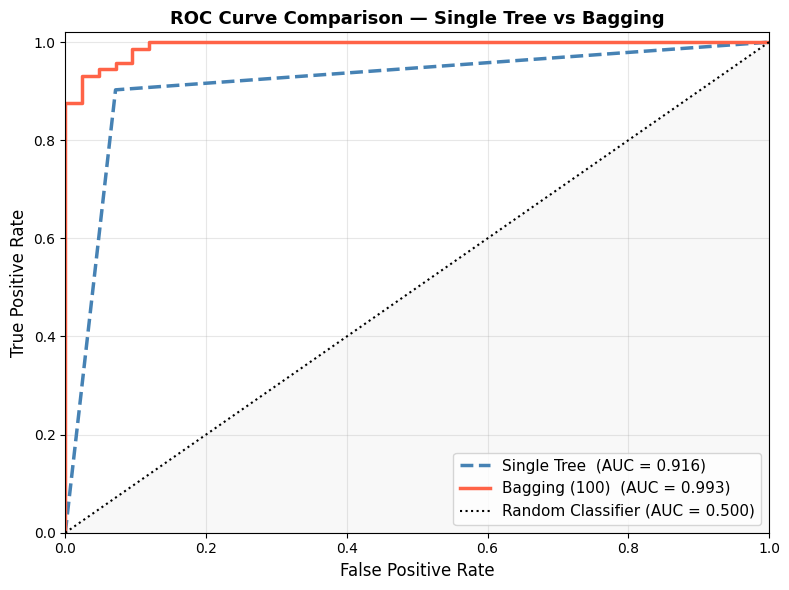

In [ ]:
#  PART F — ROC Curve Comparison

fig, ax = plt.subplots(figsize=(8, 6))

models_roc = {
    'Single Tree': single_tree,
    'Bagging (100)': bagging_clf,
}
colors_roc = ['steelblue', 'tomato']
styles_roc  = ['--', '-']

for (name, model), col, ls in zip(models_roc.items(), colors_roc, styles_roc):
    proba   = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linestyle=ls, color=col, linewidth=2.5,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], [0, 0], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — Single Tree vs Bagging', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

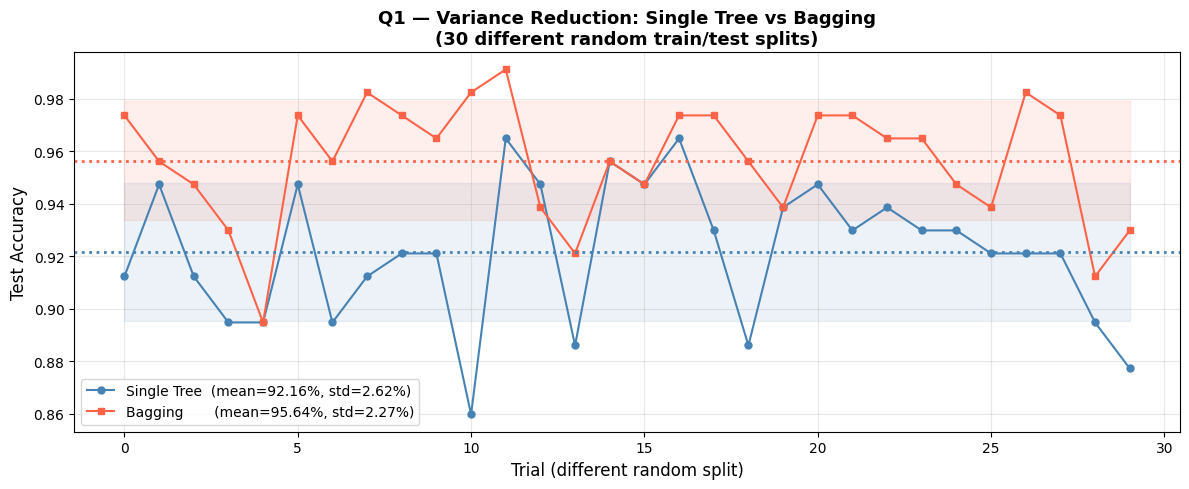

Single Tree Variance : 6.8705 × 10⁻⁴
Bagging    Variance  : 5.1546 × 10⁻⁴
Variance Reduction   : 25.0%


In [ ]:
#  PART G — Variance Demonstration (Q1 — overfitting)
#  Run 30 different train splits → compare stability

n_trials    = 30
tree_accs   = []
bagging_accs_trial = []

for seed in range(n_trials):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                            random_state=seed)
    # Single tree
    t = DecisionTreeClassifier(random_state=seed).fit(Xtr, ytr)
    tree_accs.append(accuracy_score(yte, t.predict(Xte)))
    # Bagging
    b = BaggingClassifier(n_estimators=100, random_state=seed,
                           n_jobs=-1).fit(Xtr, ytr)
    bagging_accs_trial.append(accuracy_score(yte, b.predict(Xte)))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tree_accs, 'o-', color='steelblue', linewidth=1.5, markersize=5,
        label=f'Single Tree  (mean={np.mean(tree_accs)*100:.2f}%, std={np.std(tree_accs)*100:.2f}%)')
ax.plot(bagging_accs_trial, 's-', color='tomato', linewidth=1.5, markersize=5,
        label=f'Bagging       (mean={np.mean(bagging_accs_trial)*100:.2f}%, std={np.std(bagging_accs_trial)*100:.2f}%)')
ax.axhline(np.mean(tree_accs),  color='steelblue', linestyle=':', linewidth=2)
ax.axhline(np.mean(bagging_accs_trial), color='tomato',    linestyle=':', linewidth=2)
ax.fill_between(range(n_trials),
                [np.mean(tree_accs)-np.std(tree_accs)]*n_trials,
                [np.mean(tree_accs)+np.std(tree_accs)]*n_trials,
                alpha=0.1, color='steelblue')
ax.fill_between(range(n_trials),
                [np.mean(bagging_accs_trial)-np.std(bagging_accs_trial)]*n_trials,
                [np.mean(bagging_accs_trial)+np.std(bagging_accs_trial)]*n_trials,
                alpha=0.1, color='tomato')
ax.set_xlabel('Trial (different random split)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Q1 — Variance Reduction: Single Tree vs Bagging\n'
             '(30 different random train/test splits)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('variance_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Single Tree Variance : {np.var(tree_accs)*10000:.4f} × 10⁻⁴")
print(f"Bagging    Variance  : {np.var(bagging_accs_trial)*10000:.4f} × 10⁻⁴")
print(f"Variance Reduction   : {(1 - np.var(bagging_accs_trial)/np.var(tree_accs))*100:.1f}%")